<h1>ENSO Index ACC</h1>

![UFS-logo](../../../UFS-Logo-RGB-2csolidshorizontal-72dpi-min.png)

In [1]:
basedir = f'../../../..'

In [2]:
import os
import sys
import scipy
import xarray as xr

# Point to root directory of repository
root_dir = os.path.join(os.getcwd(), basedir)
if root_dir not in sys.path:
    sys.path.insert(0, root_dir)
    
from src.datareader import datareader as dr
from src.util import util, stats, timeutil

import warnings
warnings.filterwarnings('ignore')

<h5>User Configurables</h5>

In [3]:
ufs_experiment = 'beta1'

In [4]:
ufs_var = 'tmpsfc'
era5_var = 'sea_surface_temperature'

In [5]:
time_range = ("1991-01-01", "2020-12-31T23")
initmonths = (3,4,5,11)

In [6]:
# For ENSO, the reference region is:
region = {
    'latmin': -5.0,
    'latmax': 5.0,
    'lonmin': 190.0,
    'lonmax': 240.0
}

<h5>Get data readers</h5>

<h5>UFS Beta1 data are currently being released per initmonth, so we need to extract separately and combine.</h5>

In [7]:
ufs_datasets = []  # List of datasets, one per initmonth

for this_initmonth in initmonths:
    # Convert 3 to '03'
    this_initmonth = str(this_initmonth).zfill(2)
    this_filename = f"experiments/{ufs_experiment}/reforecast/{this_initmonth}/atm_monthly.zarr"
    ufs_datasets.append(dr.getDataReader(datasource='UFS', filename=this_filename, model='atm').dataset())

Reading data from s3://noaa-oar-sfsdev-pds/experiments/beta1/reforecast/03/atm_monthly.zarr
Reading data from s3://noaa-oar-sfsdev-pds/experiments/beta1/reforecast/04/atm_monthly.zarr
Reading data from s3://noaa-oar-sfsdev-pds/experiments/beta1/reforecast/05/atm_monthly.zarr
Reading data from s3://noaa-oar-sfsdev-pds/experiments/beta1/reforecast/11/atm_monthly.zarr


In [8]:
# Combine datasets and form into a DataReader object.
concat_ds = xr.concat(ufs_datasets, dim='init')
concat_ds = concat_ds.sortby('init')

ufs_data_reader = dr.getDataReader(datasource='UFS', filename=this_filename, model='atm')
ufs_data_reader.update(ds=concat_ds)
del concat_ds

Reading data from s3://noaa-oar-sfsdev-pds/experiments/beta1/reforecast/11/atm_monthly.zarr
Dataset updated.


In [9]:
# Get ERA5 data
era5_data_reader = dr.getDataReader(datasource='ERA5')

No filename provided; deferring to default
Reading data from gs://gcp-public-data-arco-era5/ar/1959-2022-6h-512x256_equiangular_conservative.zarr


In [10]:
ufs_data_reader.describe(ufs_var)


Variable: tmpsfc
Dimensions: ('init', 'lead', 'member', 'lat', 'lon')
Shape: (139, 12, 11, 361, 720)
Attributes:


In [11]:
era5_data_reader.describe(era5_var)


Variable: sea_surface_temperature
Dimensions: ('time', 'lat', 'lon')
Shape: (92044, 256, 512)
Attributes:
  - long_name: Sea surface temperature
  - short_name: sst
  - units: K


<h5>Get the monthly climatology for nino 3.4</h5>

In [12]:
# Enter a list of members, like [1, 2, 6, 8, ens_avg]
# Note that 'ens_avg' is a special keyword in the ensuing code.
# If you include 'ens_avg' in the list of members,
# then the Ensemble Average will be listed under member = -1
members = ['ens_avg']

In [13]:
%%capture captured_output
ufs_ds = util.retrieve_ufs_dataset(ufs_data_reader, ufs_var, time_range, members, region, initmonths=initmonths)

<h5>Get the corresponding ERA5 data</h5>

In [14]:
era5_ds = era5_data_reader.retrieve(var=era5_var,
                lat=(region['latmin'], region['latmax']),
                lon=(region['lonmin'], region['lonmax']))

In [15]:
# Ensure that temporal domains perfectly match.
era5_ds = timeutil.match_time_to_leads(verif_ds=era5_ds,
                                       ufs_ds=ufs_ds)

<h2>Calculate ENSO Index</h2>

<h5>Calculate climatologies for each dataset (this may take a couple minutes)</h5>

<h5>setting area_mean=True effectively calculates ENSO Index</h5>

In [16]:
ufs_stats = stats.calc_climatology_anomaly(ufs_ds, area_mean=True, use_member_climatology=False)

In [17]:
era5_stats = stats.calc_climatology_anomaly(era5_ds, area_mean=True)

<h2>Calculate and Plot Anomaly Correlation Coefficient</h2>

<module 'matplotlib.pyplot' from '/home/thamzey/miniforge2/envs/ufs_py311/lib/python3.11/site-packages/matplotlib/pyplot.py'>

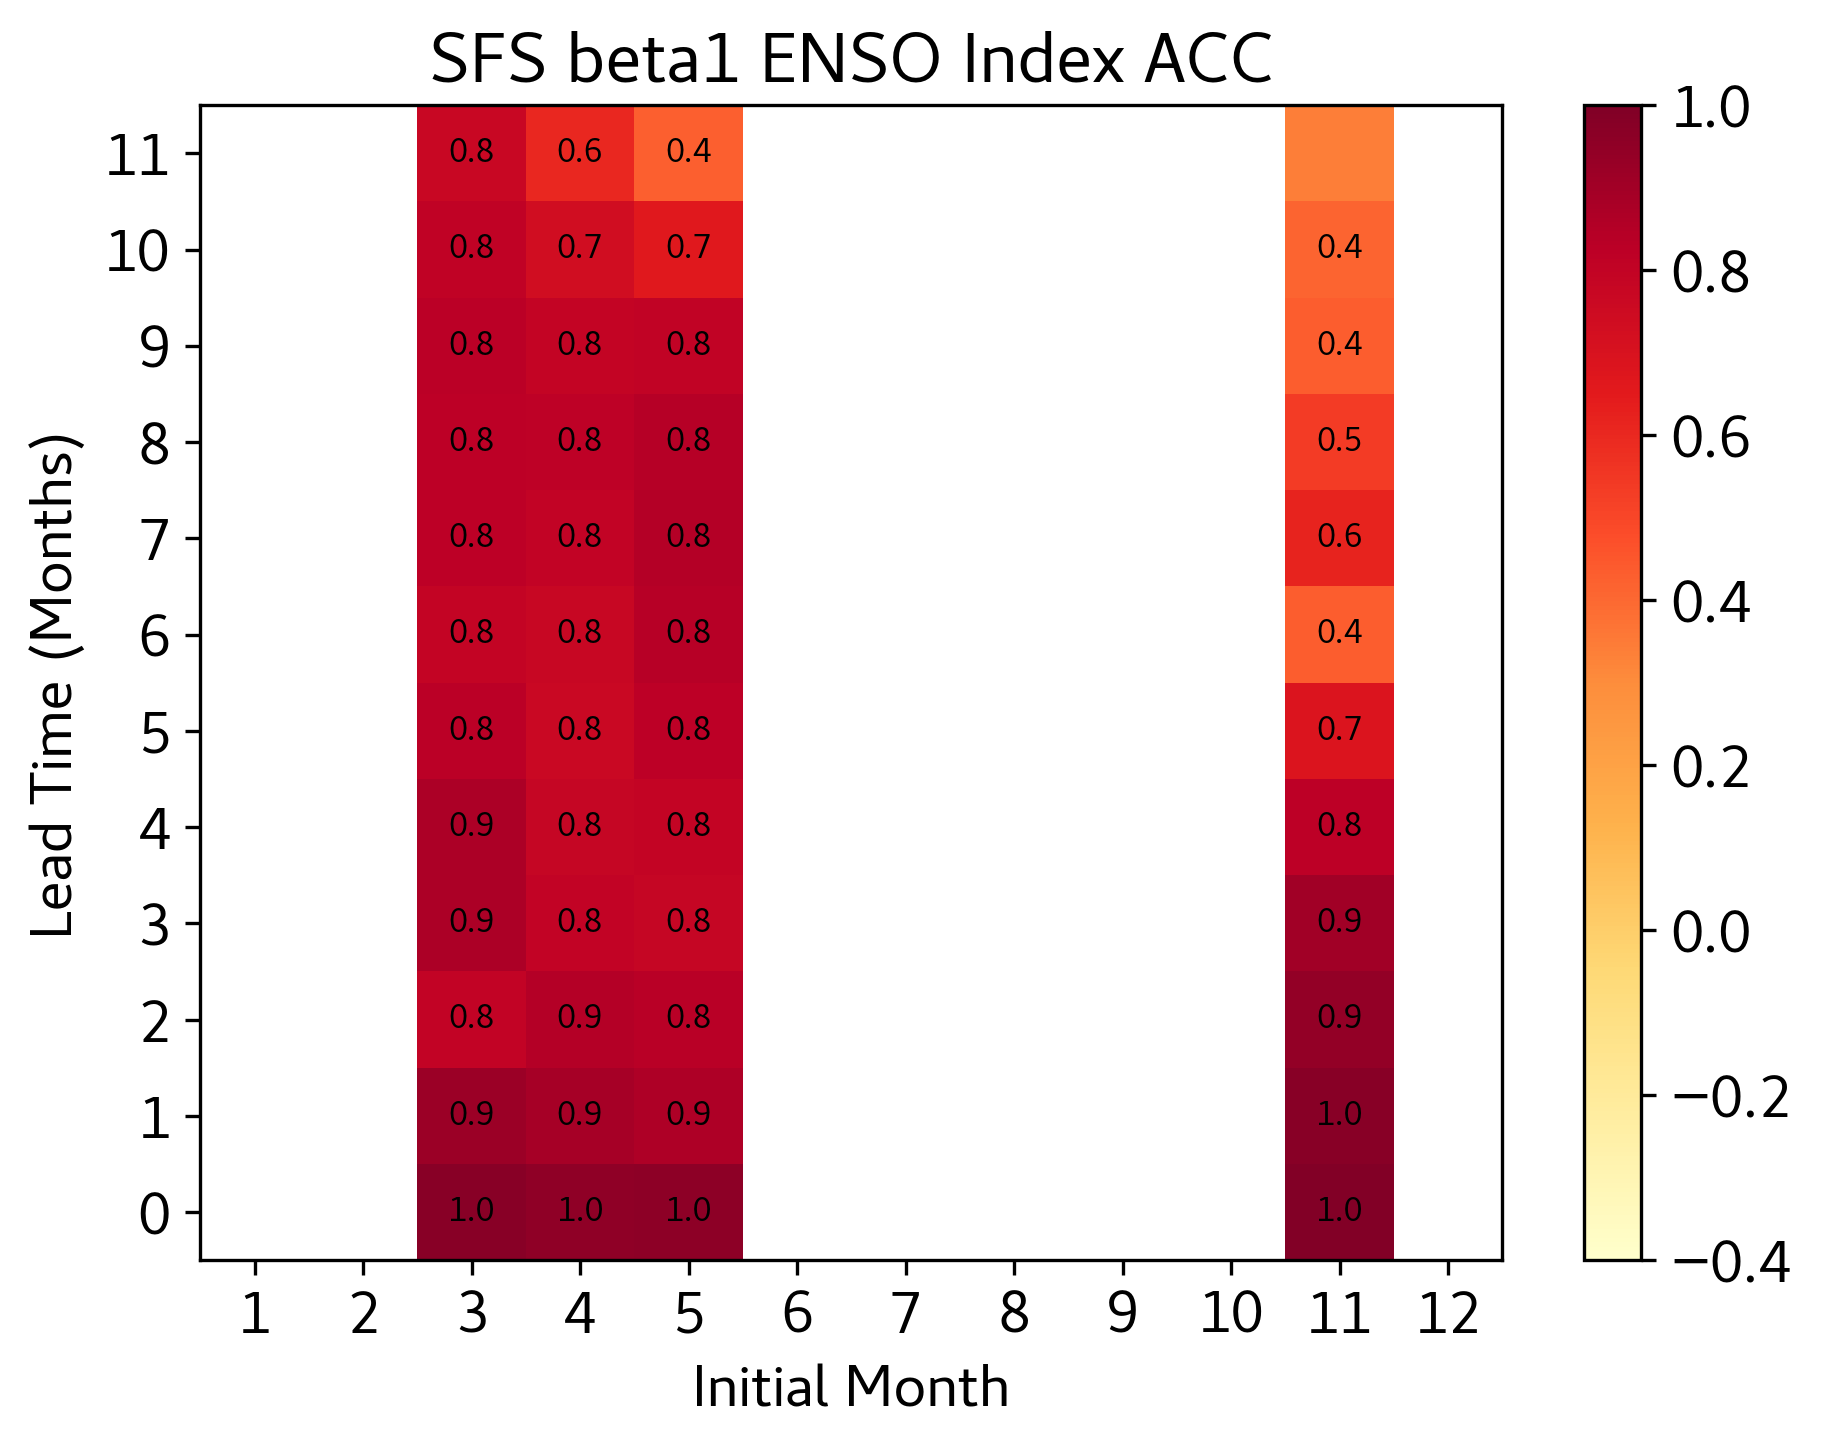

In [22]:
stats.plot_acc_heatmap(ufs_da=ufs_stats['monthly_mean'],
                       verif_da=era5_stats['monthly_mean'],
                       title=f'SFS {ufs_experiment} ENSO Index ACC',
                       sigalpha=0.05,
                       dpi=300)